# Model Explainability

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, roc_auc_score, roc_curve

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [2]:
features = pd.read_parquet(DATA_DIR / "application_features.parquet")
split_assignments = pd.read_parquet(DATA_DIR / "split_assignments.parquet")
data = features.merge(
    split_assignments[["SK_ID_CURR", "SPLIT"]],
    on="SK_ID_CURR",
    how="inner",
    validate="one_to_one",
)

excluded_cols = ["TARGET", "SK_ID_CURR", "SPLIT"]
train_data = data[data["SPLIT"].eq("train")].copy()
holdout_data = data[data["SPLIT"].eq("test")].copy()
X_train = train_data.drop(columns=excluded_cols)
y_train = train_data["TARGET"].astype("int8")
X_holdout = holdout_data.drop(columns=excluded_cols)
y_holdout = holdout_data["TARGET"].astype("int8")
holdout_ids = holdout_data["SK_ID_CURR"]

model_bundle = joblib.load(MODEL_DIR / "credit_scoring_feature_pipeline.pkl")
model_metadata = json.loads((MODEL_DIR / "model_metadata.json").read_text())
pipeline = model_bundle["pipeline"]
input_features = model_bundle["input_features"]
X_train = train_data[input_features].copy()
X_holdout = holdout_data[input_features].copy()
if "CUSTOMER_SEGMENT" in input_features:
    X_train["CUSTOMER_SEGMENT"] = X_train["CUSTOMER_SEGMENT"].astype("string")
    X_holdout["CUSTOMER_SEGMENT"] = X_holdout["CUSTOMER_SEGMENT"].astype("string")
decision_threshold = float(model_bundle["decision_threshold"])
model = pipeline.named_steps["model"]
if "device" in model.get_params():
    model.set_params(device="cpu")
if "n_jobs" in model.get_params():
    model.set_params(n_jobs=-1)

holdout_probabilities = pipeline.predict_proba(X_holdout)[:, 1]
print(f"Model: {model_metadata['selected_model']}")
print(f"Training rows: {len(X_train):,}")
print(f"Holdout rows: {len(X_holdout):,}")
print(f"Decision threshold: {decision_threshold:.4f}")

Model: Gradient Boost
Training rows: 246,008
Holdout rows: 61,503
Decision threshold: 0.6885


## Financial Performance

In [3]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype("int8")
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    auroc = roc_auc_score(y_true, probabilities)
    return {
        "AUROC": auroc,
        "Gini": 2 * auroc - 1,
        "KS": float(np.max(tpr - fpr)),
        "AUPRC": average_precision_score(y_true, probabilities),
        "F1": f1_score(y_true, predictions),
        "Brier": brier_score_loss(y_true, probabilities),
        "Threshold": threshold,
    }

holdout_metrics = evaluate_probabilities(
    y_holdout,
    holdout_probabilities,
    decision_threshold,
)
metrics_table = pd.Series(holdout_metrics, name="Holdout").to_frame()
display(metrics_table.style.format("{:.4f}"))

,Holdout
AUROC,0.7685
Gini,0.5371
KS,0.3994
AUPRC,0.2609
F1,0.3179
Brier,0.1876
Threshold,0.6885


Cross-Validation Stability

In [4]:
fold_scores = pd.read_csv(REPORT_DIR / "cross_validation_scores.csv")
cv_summary = fold_scores[["AUROC", "AUPRC"]].agg(["mean", "std"]).T
display(fold_scores.style.format({"AUROC": "{:.4f}", "AUPRC": "{:.4f}"}))
display(cv_summary.style.format("{:.4f}"))

,Fold,AUROC,AUPRC
0,1,0.7632,0.2460
1,2,0.7637,0.2481
2,3,0.7628,0.2494
3,4,0.7650,0.2486
4,5,0.7652,0.2500


,mean,std
AUROC,0.7640,0.0011
AUPRC,0.2484,0.0015


SHAP Sample

In [5]:
preprocessor = pipeline.named_steps["preprocessor"]
feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=str)
shap_sample = X_holdout.sample(n=min(1_000, len(X_holdout)), random_state=42)
transformed_sample = preprocessor.transform(shap_sample)
if hasattr(transformed_sample, "toarray"):
    transformed_sample = transformed_sample.toarray()
transformed_sample = np.asarray(transformed_sample)
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(transformed_sample, check_additivity=False)
shap_explanation.feature_names = feature_names.tolist()
shap_explanation.data = transformed_sample

np.savez_compressed(
    MODEL_DIR / "shap_values.npz",
    values=shap_explanation.values,
    base_values=shap_explanation.base_values,
    data=transformed_sample,
    feature_names=feature_names,
    row_indices=shap_sample.index.to_numpy(),
)
print(f"Explained {len(shap_sample):,} holdout applicants across {len(feature_names):,} transformed features.")
print("Tree SHAP contributions are expressed on the model margin scale; predicted probabilities are shown separately for applicant decisions.")

Explained 1,000 holdout applicants across 250 transformed features.
Tree SHAP contributions are expressed on the model margin scale; predicted probabilities are shown separately for applicant decisions.


Global Explanations

,feature,mean_absolute_SHAP
0,EXT_SOURCE_MEAN,0.48604
1,CREDIT_TERM_PROXY,0.12615
2,CREDIT_GOODS_RATIO,0.11764
3,EDUCATION_ORDINAL,0.09413
4,AMT_ANNUITY,0.08068
5,EXT_SOURCE_MAX,0.06985
6,BUREAU_DEBT_CREDIT_RATIO,0.06550
7,EMPLOYMENT_YEARS,0.05743
8,AGE_YEARS,0.05483
9,EXT_SOURCE_3,0.05064


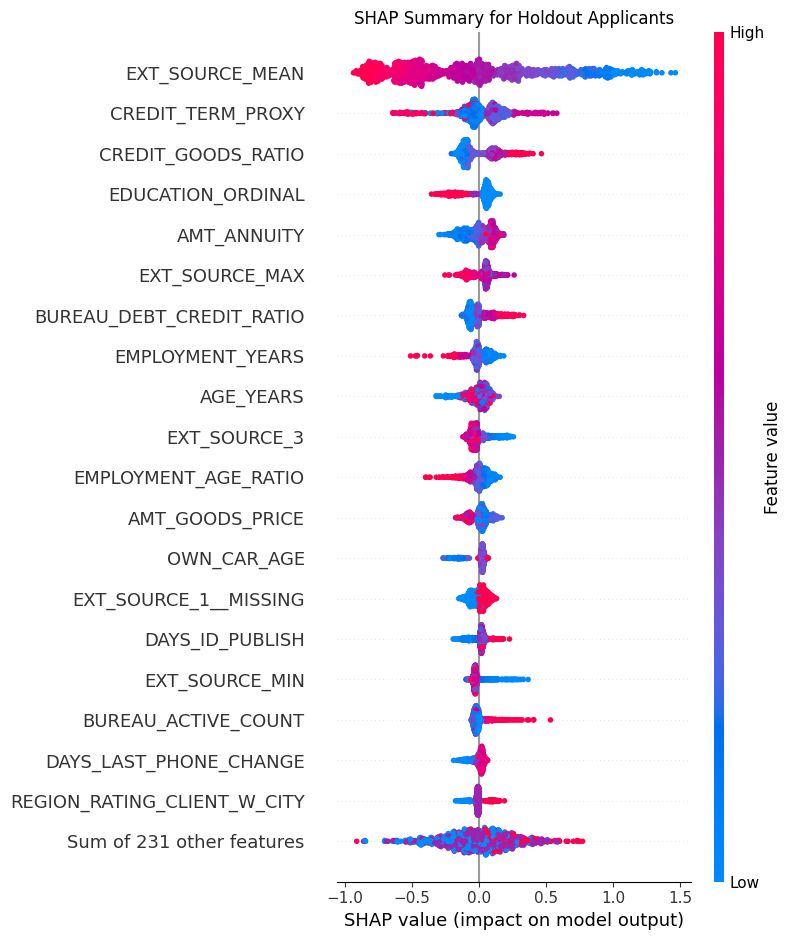

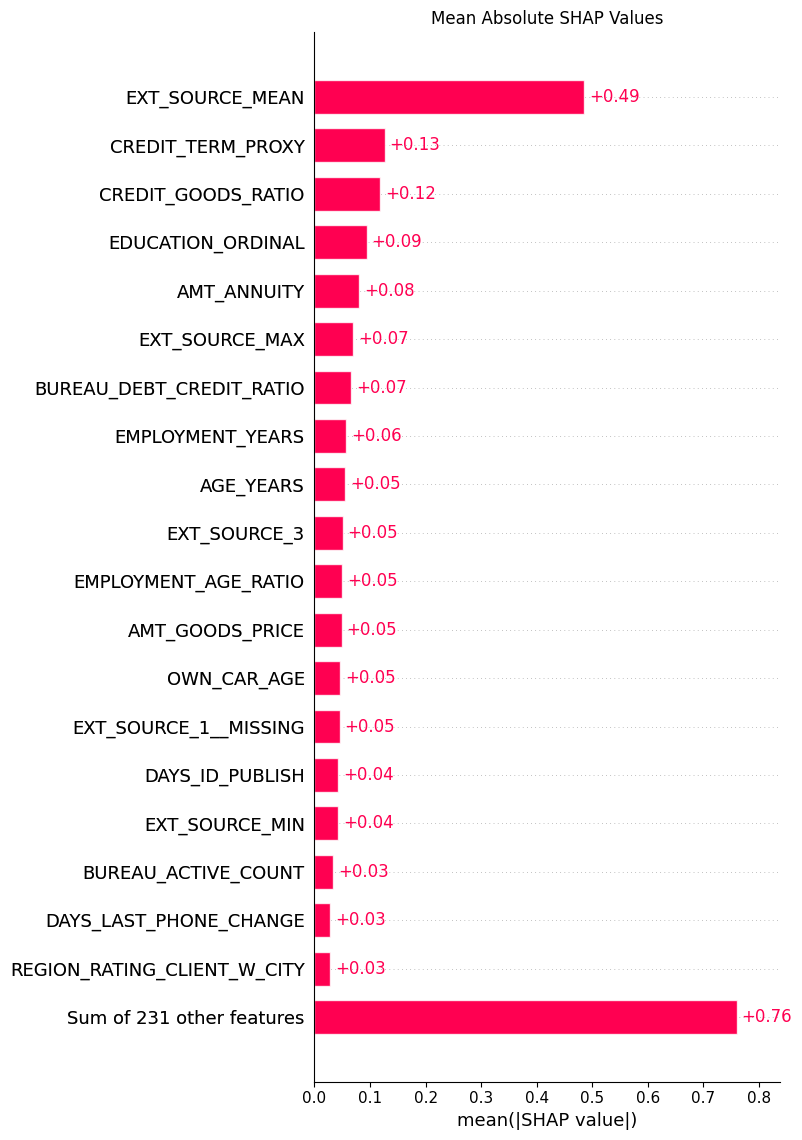

In [6]:
mean_absolute_shap = np.abs(shap_explanation.values).mean(axis=0)
feature_importance = (
    pd.DataFrame({"feature": feature_names, "mean_absolute_SHAP": mean_absolute_shap})
    .sort_values("mean_absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(20).style.format({"mean_absolute_SHAP": "{:.5f}"}))

shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("SHAP Summary for Holdout Applicants")
plt.tight_layout()
plt.show()

shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title("Mean Absolute SHAP Values")
plt.tight_layout()
plt.show()

## Applicant Selection

In [7]:
probability_series = pd.Series(holdout_probabilities, index=X_holdout.index, name="predicted_PD")

def closest_index(series, target, lower=None, upper=None):
    eligible = series.copy()
    if lower is not None:
        eligible = eligible[eligible >= lower]
    if upper is not None:
        eligible = eligible[eligible <= upper]
    if eligible.empty:
        eligible = series
    return (eligible - target).abs().idxmin()

selected_indices = {
    "High risk": closest_index(probability_series, 0.75, lower=0.50),
    "Borderline": closest_index(probability_series, 0.30, lower=0.20, upper=0.40),
    "Low risk": closest_index(probability_series, 0.05, upper=0.10),
}
selected_applicants = X_holdout.loc[list(selected_indices.values())]
selected_profiles = pd.DataFrame({
    "risk_profile": selected_indices.keys(),
    "SK_ID_CURR": [int(holdout_ids.loc[i]) for i in selected_indices.values()],
    "predicted_PD": [probability_series.loc[i] for i in selected_indices.values()],
    "decision": [
        "Decline" if probability_series.loc[i] >= decision_threshold else "Approve"
        for i in selected_indices.values()
    ],
}).set_index("risk_profile")
display(selected_profiles.style.format({"predicted_PD": "{:.2%}"}))

,SK_ID_CURR,predicted_PD,decision
risk_profile,,,
High risk,220485,75.00%,Decline
Borderline,375222,30.00%,Approve
Low risk,288902,5.00%,Approve


## Local Explanations

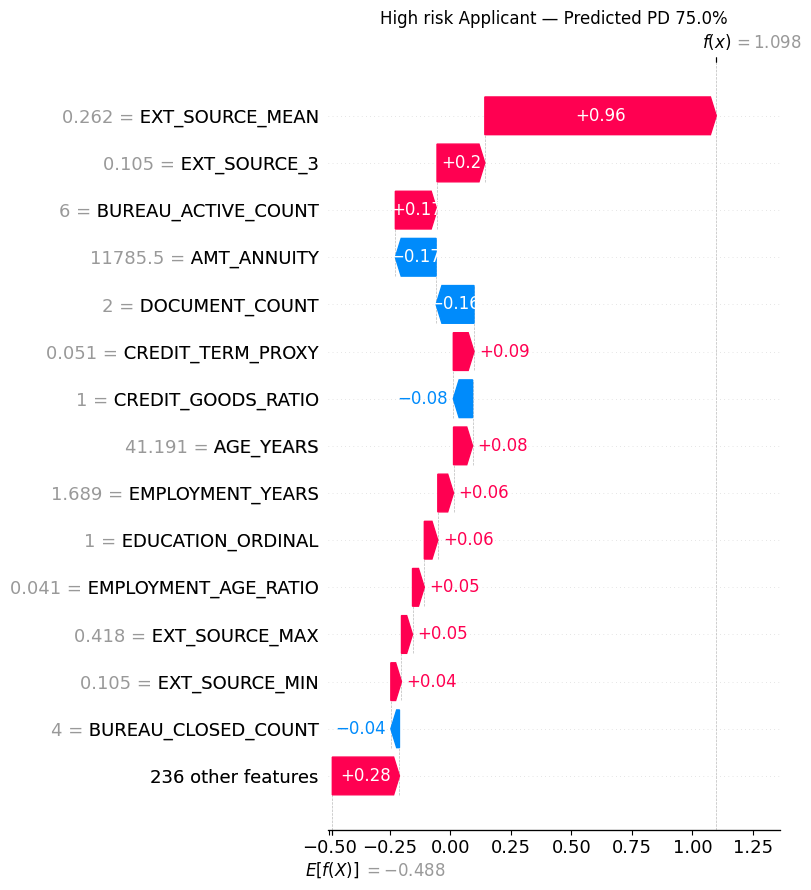

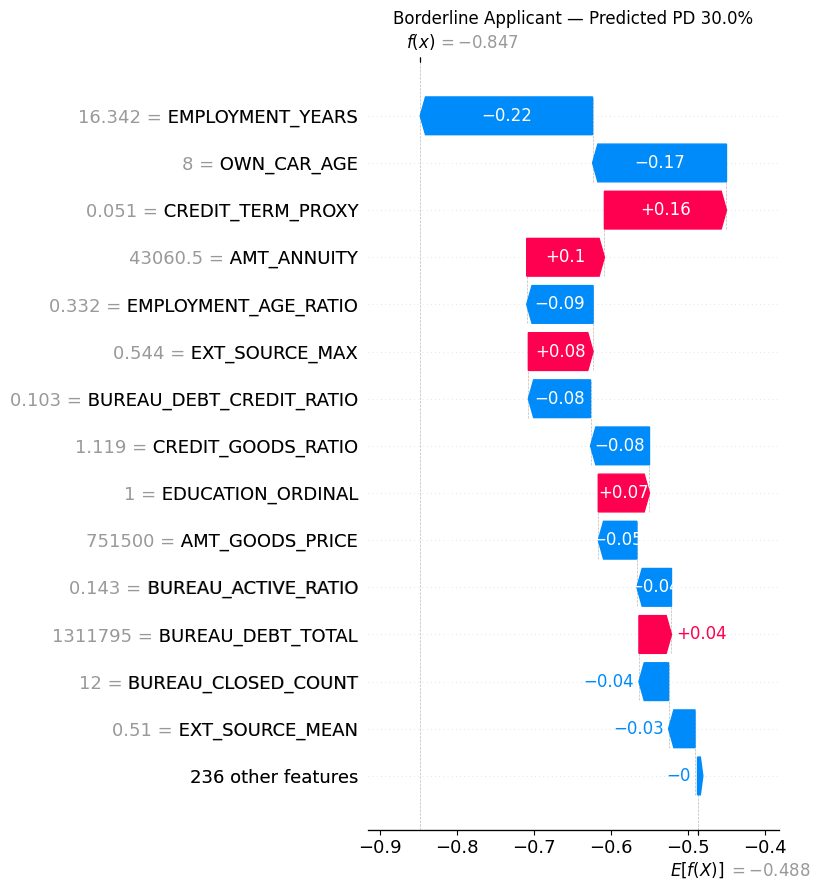

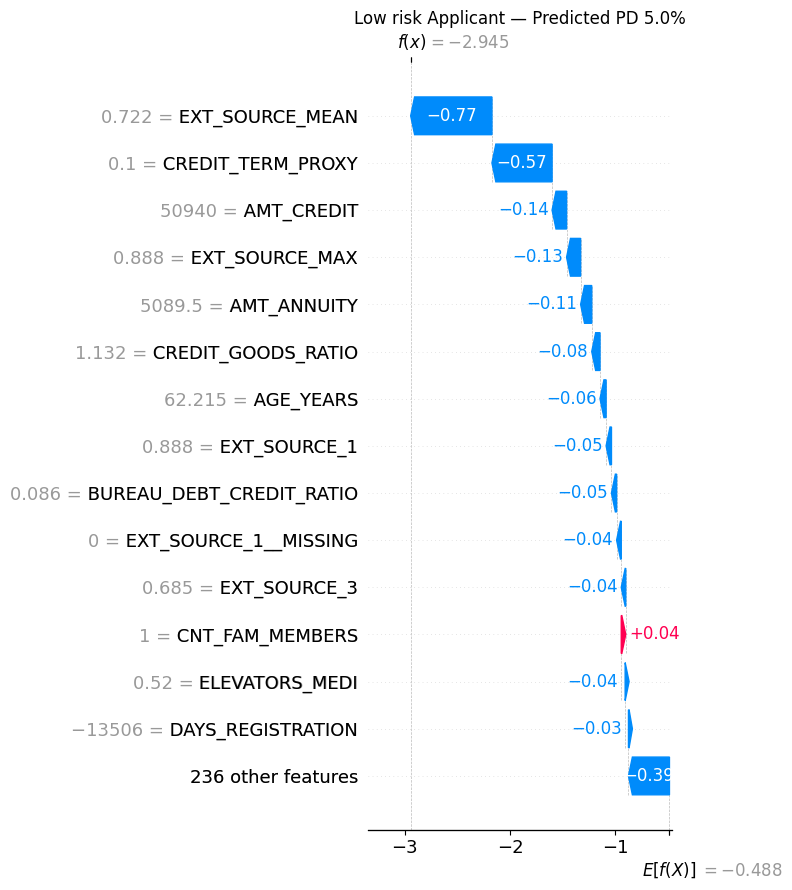

In [8]:
local_transformed = preprocessor.transform(selected_applicants)
if hasattr(local_transformed, "toarray"):
    local_transformed = local_transformed.toarray()
local_transformed = np.asarray(local_transformed)
local_explanations = explainer(local_transformed, check_additivity=False)
local_explanations.feature_names = feature_names.tolist()
local_explanations.data = local_transformed

for position, risk_profile in enumerate(selected_indices):
    shap.plots.waterfall(local_explanations[position], max_display=15, show=False)
    probability = selected_profiles.loc[risk_profile, "predicted_PD"]
    plt.title(f"{risk_profile} Applicant — Predicted PD {probability:.1%}")
    plt.tight_layout()
    plt.show()

## Adverse Action Notice

In [9]:
feature_labels = {
    "EXT_SOURCE_1": "external credit score 1",
    "EXT_SOURCE_2": "external credit score 2",
    "EXT_SOURCE_3": "external credit score 3",
    "EXT_SOURCE_MEAN": "average external credit score",
    "EXT_SOURCE_MIN": "lowest available external credit score",
    "EXT_SOURCE_MAX": "highest available external credit score",
    "CREDIT_INCOME_RATIO": "credit amount relative to income",
    "CREDIT_TERM_PROXY": "scheduled annuity relative to requested credit",
    "ANNUITY_INCOME_RATIO": "annuity payment relative to income",
    "PAYMENT_RATE": "annuity payment relative to credit amount",
    "BUREAU_DEBT_CREDIT_RATIO": "bureau debt relative to bureau credit",
    "AMT_CREDIT": "requested credit amount",
    "AMT_ANNUITY": "scheduled annuity payment",
    "AMT_INCOME_TOTAL": "reported annual income",
    "AGE_YEARS": "applicant age",
    "EDUCATION_ORDINAL": "education level",
}

def display_value(value):
    if pd.isna(value):
        return "missing"
    if isinstance(value, (int, float, np.integer, np.floating)):
        return f"{value:,.3f}"
    return str(value)

def source_feature_name(feature, available_features):
    if feature in available_features:
        return feature
    candidates = [col for col in available_features if feature.startswith(f"{col}_")]
    return max(candidates, key=len) if candidates else feature.split("__")[-1]

def adverse_reason(feature, applicant, reference_data):
    raw_feature = source_feature_name(feature, applicant.index)
    label = feature_labels.get(raw_feature, raw_feature.replace("_", " ").lower())
    if raw_feature not in applicant.index:
        return f"{label.capitalize()} increased the model's estimated probability of payment difficulty."
    value = applicant[raw_feature]
    reference = reference_data[raw_feature]
    if pd.api.types.is_numeric_dtype(reference):
        benchmark = reference.median()
        direction = "above" if value > benchmark else "below"
        return f"{label.capitalize()} was {direction} the training median ({display_value(value)} versus {display_value(benchmark)})."
    benchmark = reference.mode(dropna=True)
    benchmark_value = benchmark.iloc[0] if not benchmark.empty else np.nan
    return f"{label.capitalize()} was {display_value(value)} compared with the most common training value of {display_value(benchmark_value)}."

high_risk_position = list(selected_indices).index("High risk")
high_risk_values = local_explanations.values[high_risk_position]
positive_positions = np.flatnonzero(high_risk_values > 0)
top_positive_positions = positive_positions[np.argsort(high_risk_values[positive_positions])[::-1]][:4]
high_risk_applicant = selected_applicants.iloc[high_risk_position]
adverse_action_notice = pd.DataFrame({
    "rank": np.arange(1, len(top_positive_positions) + 1),
    "feature": feature_names[top_positive_positions],
    "SHAP_contribution": high_risk_values[top_positive_positions],
    "specific_reason": [
        adverse_reason(feature_names[i], high_risk_applicant, X_train)
        for i in top_positive_positions
    ],
}).set_index("rank")

print("Application decision: Credit declined")
print("Principal reasons for the decision:")
for rank, reason in adverse_action_notice["specific_reason"].items():
    print(f"{rank}. {reason}")
display(adverse_action_notice.style.format({"SHAP_contribution": "{:+.5f}"}))

Application decision: Credit declined
Principal reasons for the decision:
1. Average external credit score was below the training median (0.262 versus 0.524).
2. External credit score 3 was below the training median (0.105 versus 0.535).
3. Bureau active count was above the training median (6.000 versus 1.000).
4. Scheduled annuity relative to requested credit was above the training median (0.051 versus 0.050).


,feature,SHAP_contribution,specific_reason
rank,,,
1,EXT_SOURCE_MEAN,+0.95608,Average external credit score was below the training median (0.262 versus 0.524).
2,EXT_SOURCE_3,+0.19753,External credit score 3 was below the training median (0.105 versus 0.535).
3,BUREAU_ACTIVE_COUNT,+0.17215,Bureau active count was above the training median (6.000 versus 1.000).
4,CREDIT_TERM_PROXY,+0.08561,Scheduled annuity relative to requested credit was above the training median (0.051 versus 0.050).


## Population Stability

In [10]:
def transformed_columns_in_batches(fitted_preprocessor, frame, column_positions, batch_size=25_000):
    batches = []
    for start in range(0, len(frame), batch_size):
        transformed = fitted_preprocessor.transform(frame.iloc[start:start + batch_size])
        selected = transformed[:, column_positions]
        if hasattr(selected, "toarray"):
            selected = selected.toarray()
        batches.append(np.asarray(selected))
    return np.vstack(batches)

def population_stability_index(expected, actual, bins=10, epsilon=1e-6):
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    expected_missing = np.isnan(expected)
    actual_missing = np.isnan(actual)
    expected_valid = expected[~expected_missing]
    actual_valid = actual[~actual_missing]
    breakpoints = np.unique(np.quantile(expected_valid, np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 2:
        breakpoints = np.array([-np.inf, np.inf])
    else:
        breakpoints[0] = -np.inf
        breakpoints[-1] = np.inf
    expected_counts = np.histogram(expected_valid, bins=breakpoints)[0].astype(float)
    actual_counts = np.histogram(actual_valid, bins=breakpoints)[0].astype(float)
    expected_counts = np.append(expected_counts, expected_missing.sum())
    actual_counts = np.append(actual_counts, actual_missing.sum())
    expected_pct = np.clip(expected_counts / len(expected), epsilon, None)
    actual_pct = np.clip(actual_counts / len(actual), epsilon, None)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

top_features = feature_importance.head(10)["feature"].tolist()
top_positions = [int(np.flatnonzero(feature_names == feature)[0]) for feature in top_features]
training_top_values = transformed_columns_in_batches(preprocessor, X_train, top_positions)
holdout_top_values = transformed_columns_in_batches(preprocessor, X_holdout, top_positions)
psi_report = pd.DataFrame({
    "feature": top_features,
    "PSI": [
        population_stability_index(training_top_values[:, i], holdout_top_values[:, i])
        for i in range(len(top_features))
    ],
})
psi_report["status"] = pd.cut(
    psi_report["PSI"],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=["Stable", "Moderate shift", "Significant shift"],
    right=False,
)
psi_report = psi_report.sort_values("PSI", ascending=False).reset_index(drop=True)
display(psi_report.style.format({"PSI": "{:.4f}"}))

,feature,PSI,status
0,EXT_SOURCE_3,0.0003,Stable
1,EXT_SOURCE_MAX,0.0003,Stable
2,AMT_ANNUITY,0.0003,Stable
3,CREDIT_TERM_PROXY,0.0003,Stable
4,EMPLOYMENT_YEARS,0.0002,Stable
5,AGE_YEARS,0.0002,Stable
6,EXT_SOURCE_MEAN,0.0002,Stable
7,CREDIT_GOODS_RATIO,0.0001,Stable
8,BUREAU_DEBT_CREDIT_RATIO,0.0001,Stable
9,EDUCATION_ORDINAL,0.0000,Stable


## Monitoring Dashboard

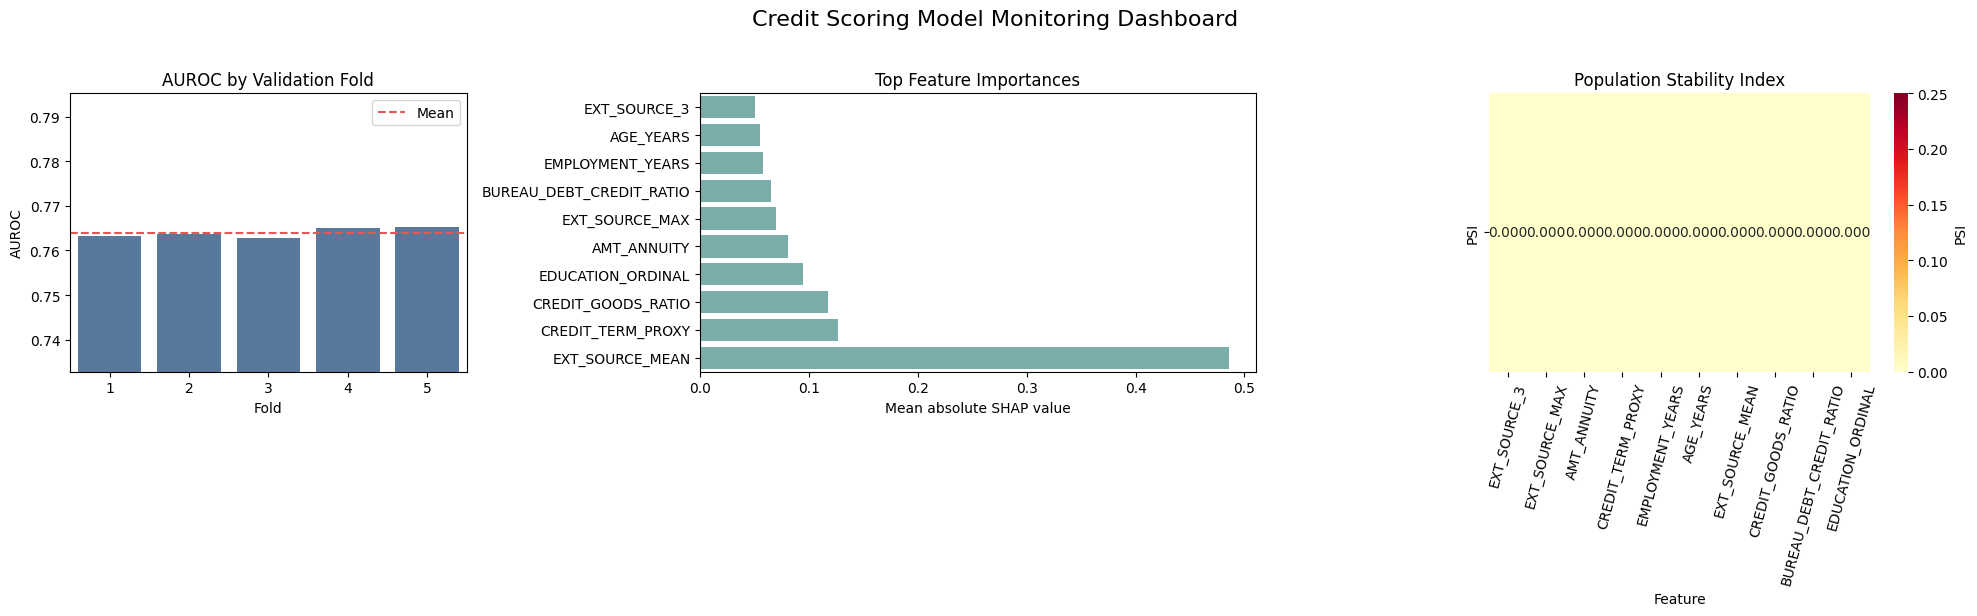

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.0, 1.4, 1.2]})

sns.barplot(data=fold_scores, x="Fold", y="AUROC", color="#4C78A8", ax=axes[0])
axes[0].axhline(fold_scores["AUROC"].mean(), color="#E45756", linestyle="--", label="Mean")
axes[0].set_ylim(max(0.5, fold_scores["AUROC"].min() - 0.03), min(1.0, fold_scores["AUROC"].max() + 0.03))
axes[0].set_title("AUROC by Validation Fold")
axes[0].legend()

importance_plot = feature_importance.head(10).sort_values("mean_absolute_SHAP")
sns.barplot(data=importance_plot, x="mean_absolute_SHAP", y="feature", color="#72B7B2", ax=axes[1])
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Mean absolute SHAP value")
axes[1].set_ylabel("")

psi_heatmap = psi_report.set_index("feature")[["PSI"]].T
sns.heatmap(
    psi_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=max(0.25, float(psi_report["PSI"].max())),
    cbar_kws={"label": "PSI"},
    ax=axes[2],
)
axes[2].set_title("Population Stability Index")
axes[2].set_xlabel("Feature")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=75)

fig.suptitle("Credit Scoring Model Monitoring Dashboard", fontsize=16, y=1.02)
plt.tight_layout()
dashboard_path = REPORT_DIR / "model_monitoring_dashboard.png"
fig.savefig(dashboard_path, dpi=200, bbox_inches="tight")
plt.show()

## Saved Outputs

In [12]:
metrics_table.to_csv(REPORT_DIR / "holdout_financial_metrics.csv")
fold_scores.to_csv(REPORT_DIR / "cross_validation_scores.csv", index=False)
feature_importance.to_csv(REPORT_DIR / "shap_feature_importance.csv", index=False)
adverse_action_notice.to_csv(REPORT_DIR / "adverse_action_notice.csv")
psi_report.to_csv(REPORT_DIR / "population_stability_index.csv", index=False)

saved_outputs = pd.Series({
    "SHAP values": MODEL_DIR / "shap_values.npz",
    "Financial metrics": REPORT_DIR / "holdout_financial_metrics.csv",
    "Cross-validation scores": REPORT_DIR / "cross_validation_scores.csv",
    "SHAP feature importance": REPORT_DIR / "shap_feature_importance.csv",
    "Adverse action notice": REPORT_DIR / "adverse_action_notice.csv",
    "Population stability": REPORT_DIR / "population_stability_index.csv",
    "Monitoring dashboard": dashboard_path,
}, name="path")
display(saved_outputs.to_frame())

,path
SHAP values,..\models\shap_values.npz
Financial metrics,..\reports\holdout_financial_metrics.csv
Cross-validation scores,..\reports\cross_validation_scores.csv
SHAP feature importance,..\reports\shap_feature_importance.csv
Adverse action notice,..\reports\adverse_action_notice.csv
Population stability,..\reports\population_stability_index.csv
Monitoring dashboard,..\reports\model_monitoring_dashboard.png
